In [1]:
# Cell 1: Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set style for professional plots
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("tab10")



In [2]:
# Cell 2: Simulate 48 hours of correlated sensor data
np.random.seed(42)

# Time array: 48 hours, reading every 10 minutes (288 readings total)
hours = 48
readings_per_hour = 6  # Every 10 minutes
n_readings = hours * readings_per_hour  # 288 readings
t = np.linspace(0, hours, n_readings)

# Temperature: daily cycle (peak at 2 PM, min at 2 AM)
temp_base = 25 + 8 * np.sin(2 * np.pi * (t - 6) / 24)
temp_noise = np.random.normal(0, 0.5, n_readings)
temperature = temp_base + temp_noise

# Vibration: increases with temperature (machines vibrate more when hot)
vibration = 0.5 + 0.03 * (temperature - 25) + np.random.normal(0, 0.05, n_readings)

# Current: also correlates with temperature (motors draw more current)
current = 10 + 0.3 * (temperature - 25) + np.random.normal(0, 0.3, n_readings)

# Humidity: inversely related to temperature (drops when hot)
humidity = 70 - 1.2 * (temperature - 25) + np.random.normal(0, 3, n_readings)
humidity = np.clip(humidity, 20, 95)  # Keep within realistic range

# Create timestamps
start_time = datetime(2025, 5, 12, 0, 0, 0)
timestamps = [start_time + timedelta(minutes=i*10) for i in range(n_readings)]

# Create DataFrame
df = pd.DataFrame({
    'timestamp': timestamps,
    'temperature_c': temperature,
    'vibration_mm_s': vibration,
    'current_a': current,
    'humidity_pct': humidity
})

print(f"📊 Generated {len(df)} readings over {hours} hours")
print(f"   Columns: {list(df.columns)}")
print(f"\nFirst 5 readings:")
print(df.head())

📊 Generated 288 readings over 48 hours
   Columns: ['timestamp', 'temperature_c', 'vibration_mm_s', 'current_a', 'humidity_pct']

First 5 readings:
            timestamp  temperature_c  vibration_mm_s  current_a  humidity_pct
0 2025-05-12 00:00:00      17.248357        0.281500   7.745191     77.463605
1 2025-05-12 00:10:00      16.938535        0.227021   7.812820     78.510653
2 2025-05-12 00:20:00      17.354499        0.260229   7.262774     80.032197
3 2025-05-12 00:30:00      17.830433        0.260263   8.192256     79.606851
4 2025-05-12 00:40:00      17.005308        0.230691   7.703141     81.569264


In [3]:
# Cell 3: Quick statistical summary
print("\n📈 DATA STATISTICS:")
print(df.describe())

# Check correlations
print("\n🔗 CORRELATION MATRIX:")
print(df[['temperature_c', 'vibration_mm_s', 'current_a', 'humidity_pct']].corr().round(3))


📈 DATA STATISTICS:
                 timestamp  temperature_c  vibration_mm_s   current_a  \
count                  288     288.000000      288.000000  288.000000   
mean   2025-05-12 23:55:00      24.966675        0.497763   10.002565   
min    2025-05-12 00:00:00      16.054611        0.158268    6.861660   
25%    2025-05-12 11:57:30      19.266140        0.341693    8.366500   
50%    2025-05-12 23:55:00      25.038304        0.487832   10.077912   
75%    2025-05-13 11:52:30      30.753706        0.659987   11.680092   
max    2025-05-13 23:50:00      34.628676        0.844078   13.212837   
std                    NaN       5.714987        0.176353    1.740663   

       humidity_pct  
count    288.000000  
mean      70.487161  
min       54.260162  
25%       64.145349  
50%       70.531780  
75%       77.098113  
max       85.541955  
std        7.657798  

🔗 CORRELATION MATRIX:
                temperature_c  vibration_mm_s  current_a  humidity_pct
temperature_c           1.000 

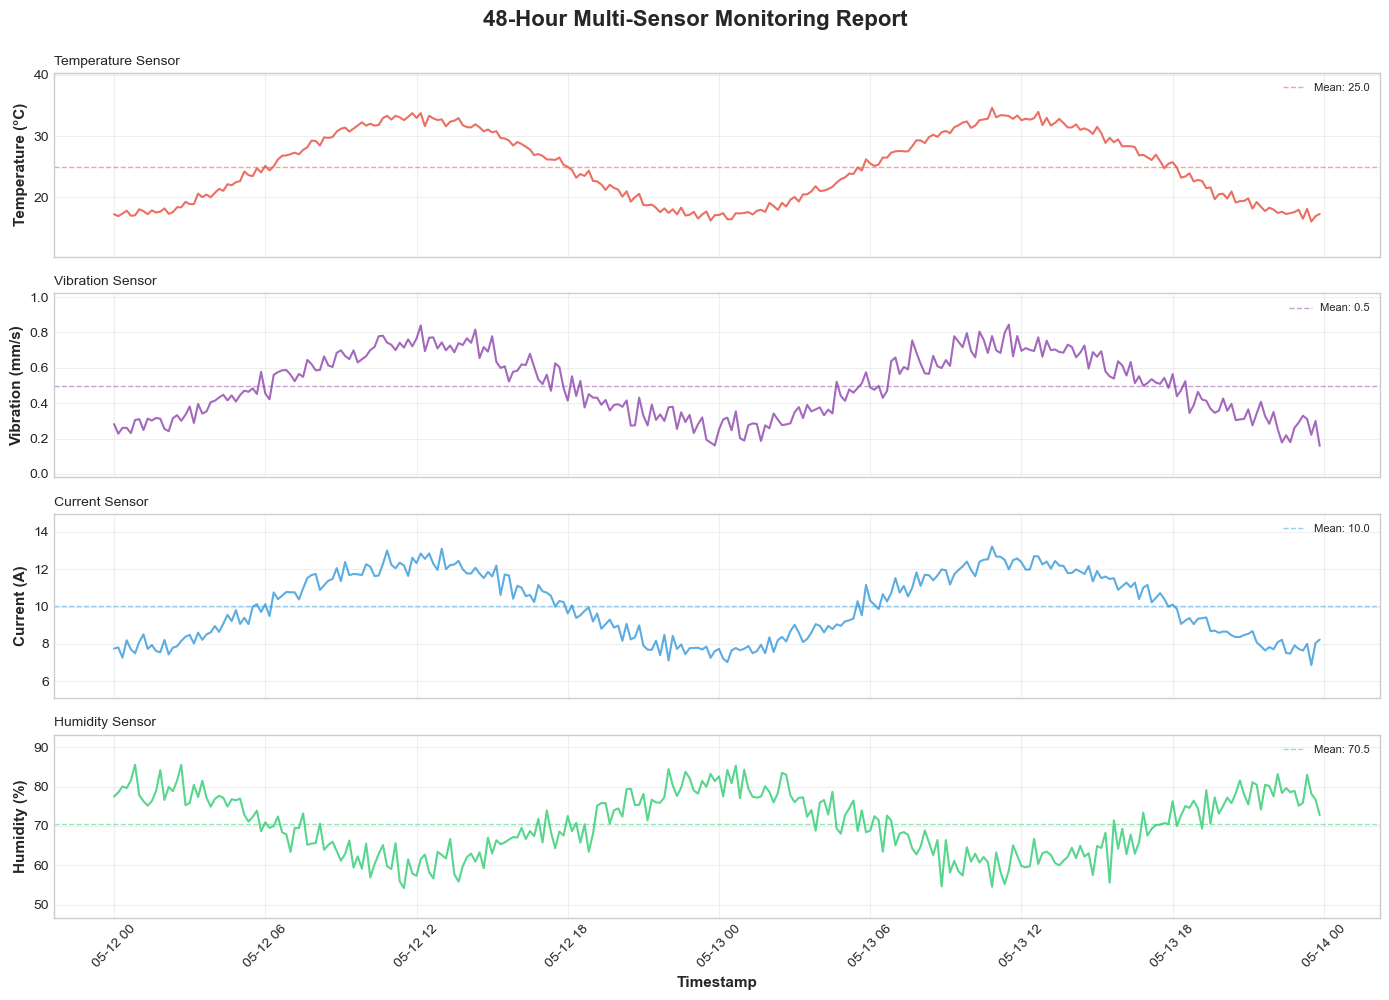

✅ Time-series figure saved as 'timeseries_48h.png'


In [5]:
# Cell 4: Multi-panel time-series plot (the main visualization)
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle('48-Hour Multi-Sensor Monitoring Report', fontsize=16, fontweight='bold', y=0.995)

# Color scheme for each sensor
colors = ['#E74C3C', '#8E44AD', '#3498DB', '#2ECC71']
y_labels = ['Temperature (°C)', 'Vibration (mm/s)', 'Current (A)', 'Humidity (%)']
titles = ['Temperature Sensor', 'Vibration Sensor', 'Current Sensor', 'Humidity Sensor']

for i, (ax, col, color, ylabel, title) in enumerate(zip(axes, 
                                                          ['temperature_c', 'vibration_mm_s', 'current_a', 'humidity_pct'],
                                                          colors, y_labels, titles)):
    ax.plot(df['timestamp'], df[col], color=color, linewidth=1.5, alpha=0.8)
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=10, loc='left')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(df[col].min() - df[col].std(), df[col].max() + df[col].std())
    
    # Add horizontal line for mean
    ax.axhline(y=df[col].mean(), color=color, linestyle='--', alpha=0.5, linewidth=1, label=f'Mean: {df[col].mean():.1f}')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Timestamp', fontsize=11, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('timeseries_48h.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Time-series figure saved as 'timeseries_48h.png'")

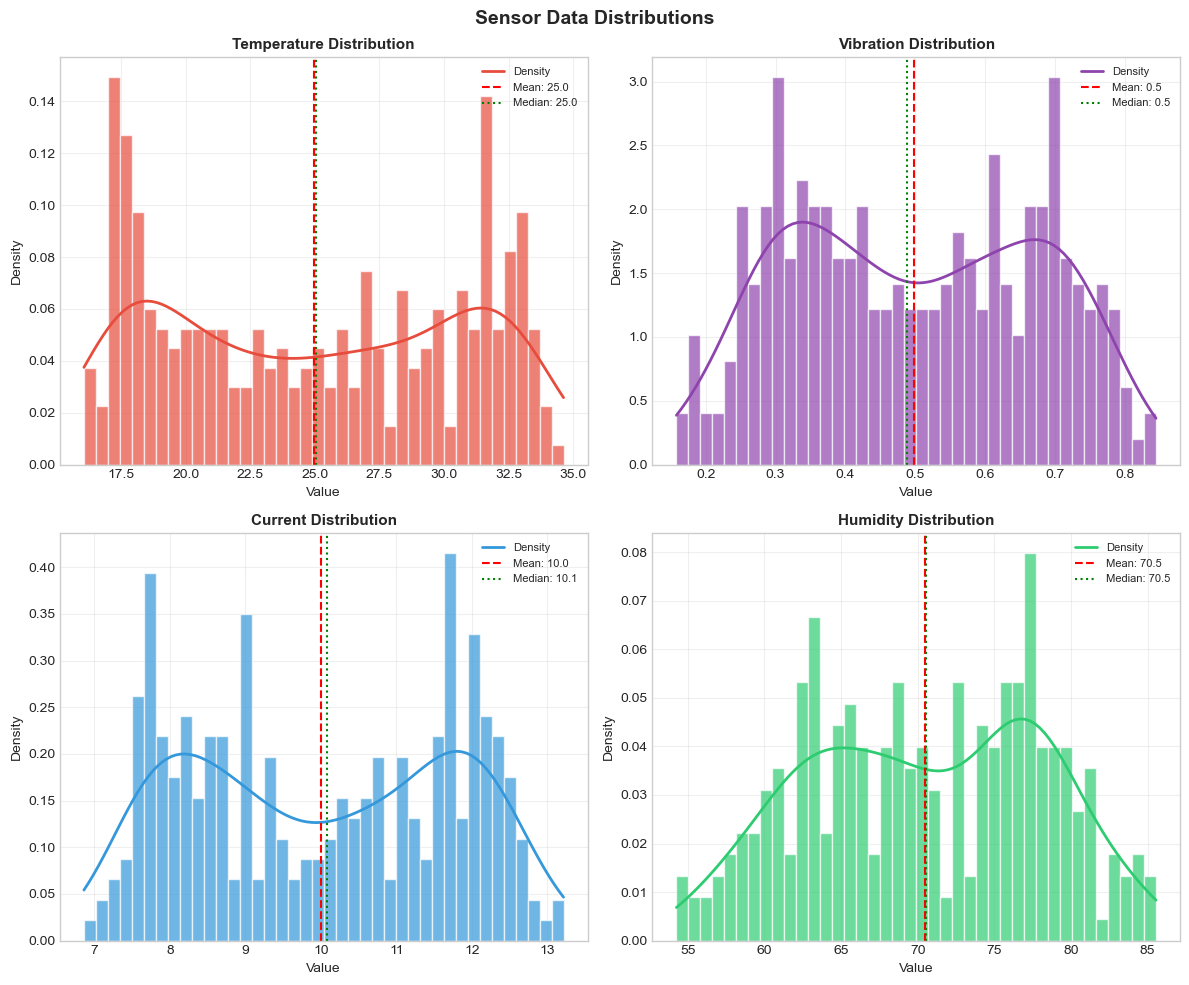

✅ Distribution plots saved as 'distributions.png'


In [6]:
# Cell 5: Distribution plots for each sensor
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Sensor Data Distributions', fontsize=14, fontweight='bold')

sensors = ['temperature_c', 'vibration_mm_s', 'current_a', 'humidity_pct']
titles = ['Temperature Distribution', 'Vibration Distribution', 'Current Distribution', 'Humidity Distribution']
colors = ['#E74C3C', '#8E44AD', '#3498DB', '#2ECC71']

for i, (ax, sensor, title, color) in enumerate(zip(axes.flat, sensors, titles, colors)):
    # Plot histogram
    ax.hist(df[sensor], bins=40, color=color, alpha=0.7, edgecolor='white', density=True)
    
    # Overlay KDE (smoothed distribution)
    from scipy import stats
    kde = stats.gaussian_kde(df[sensor])
    x_range = np.linspace(df[sensor].min(), df[sensor].max(), 100)
    ax.plot(x_range, kde(x_range), color=color, linewidth=2, label='Density')
    
    # Add vertical lines for mean and median
    ax.axvline(df[sensor].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[sensor].mean():.1f}')
    ax.axvline(df[sensor].median(), color='green', linestyle=':', linewidth=1.5, label=f'Median: {df[sensor].median():.1f}')
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Distribution plots saved as 'distributions.png'")

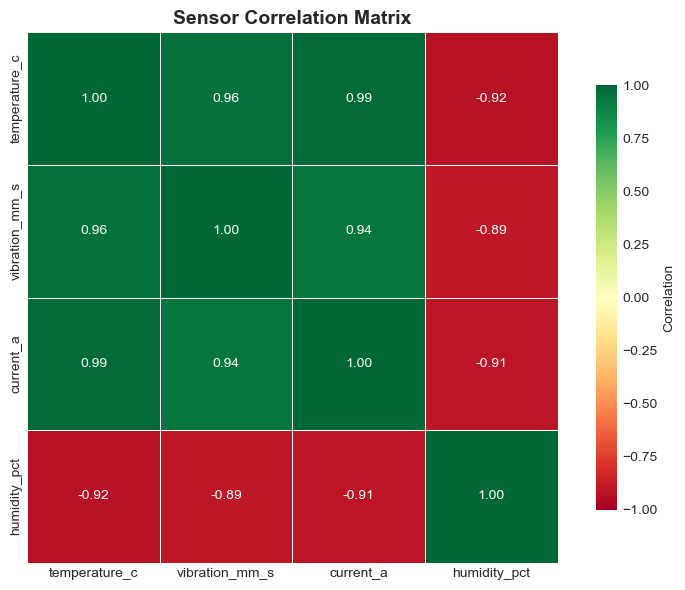

✅ Correlation heatmap saved as 'correlation_heatmap.png'

📊 INTERPRETATION:
   • Red/positive = sensors increase together
   • Blue/negative = one increases, other decreases
   • Temperature and current are positively correlated (expected)
   • Temperature and humidity are negatively correlated (expected)


In [7]:
# Cell 6: Correlation heatmap - shows which sensors move together
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate correlation matrix
corr_matrix = df[['temperature_c', 'vibration_mm_s', 'current_a', 'humidity_pct']].corr()

# Create heatmap
sns.heatmap(corr_matrix, 
            annot=True,           # Show correlation values
            fmt='.2f',            # 2 decimal places
            cmap='RdYlGn',        # Red-Yellow-Green (negative to positive)
            vmin=-1, vmax=1,      # Correlation range
            square=True,          # Square cells
            linewidths=0.5,       # Lines between cells
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax)

# Customize
ax.set_title('Sensor Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Correlation heatmap saved as 'correlation_heatmap.png'")
print("\n📊 INTERPRETATION:")
print("   • Red/positive = sensors increase together")
print("   • Blue/negative = one increases, other decreases")
print("   • Temperature and current are positively correlated (expected)")
print("   • Temperature and humidity are negatively correlated (expected)")

In [10]:
# Cell 7: Create an HTML report embedding all figures
import base64
import io

def fig_to_base64(fig):
    """Convert matplotlib figure to base64 string for HTML embedding"""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    buf.close()
    return img_base64

# Generate the base64 strings for each figure (you'd need to recreate or reuse figures)
# For this demonstration, I'll show the structure

html_content = """
<!DOCTYPE html>
<html>
<head>
    <title>Multi-Sensor Monitoring Report</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 40px; }
        h1 { color: #2c3e50; border-bottom: 3px solid #3498db; }
        h2 { color: #34495e; margin-top: 30px; }
        .figure { margin: 30px 0; text-align: center; }
        .figure img { max-width: 100%; border: 1px solid #ddd; border-radius: 5px; }
        .caption { color: #7f8c8d; font-size: 0.9em; margin-top: 10px; }
        table { border-collapse: collapse; width: 100%; margin: 20px 0; }
        th, td { border: 1px solid #ddd; padding: 8px; text-align: center; }
        th { background-color: #3498db; color: white; }
        .insight { background-color: #e8f4f8; padding: 15px; border-radius: 5px; margin: 20px 0; }
    </style>
</head>
<body>
    <h1>📊 Multi-Sensor Monitoring Report</h1>
    <p><strong>Report Generated:</strong> """ + datetime.now().strftime('%Y-%m-%d %H:%M:%S') + """</p>
    <p><strong>Data Period:</strong> 48 hours | <strong>Readings:</strong> 288 (every 10 minutes)</p>
    
    <div class="insight">
        <h3>🔍 Executive Summary</h3>
        <ul>
            <li><strong>Temperature range:</strong> """ + f"{df['temperature_c'].min():.1f}" + """°C - """ + f"{df['temperature_c'].max():.1f}" + """°C</li>
            <li><strong>Vibration range:</strong> """ + f"{df['vibration_mm_s'].min():.2f}" + """ - """ + f"{df['vibration_mm_s'].max():.2f}" + """ mm/s</li>
            <li><strong>Current range:</strong> """ + f"{df['current_a'].min():.1f}" + """ - """ + f"{df['current_a'].max():.1f}" + """ A</li>
            <li><strong>Humidity range:</strong> """ + f"{df['humidity_pct'].min():.0f}" + """% - """ + f"{df['humidity_pct'].max():.0f}" + """%</li>
        </ul>
    </div>
    
    <h2>📈 Time Series Analysis</h2>
    <div class="figure">
        <img src="timeseries_48h.png" alt="Time Series Plot">
        <div class="caption">Figure 1: 48-hour trends for all four sensors. Notice the daily cycles in temperature and inversely correlated humidity.</div>
    </div>
    
    <h2>📊 Distribution Analysis</h2>
    <div class="figure">
        <img src="distributions.png" alt="Distribution Plots">
        <div class="caption">Figure 2: Histograms showing value distributions with mean and median markers.</div>
    </div>
    
    <h2>🔗 Correlation Analysis</h2>
    <div class="figure">
        <img src="correlation_heatmap.png" alt="Correlation Heatmap">
        <div class="caption">Figure 3: Correlation matrix showing relationships between sensors.</div>
    </div>
    
    <h2>📋 Statistical Summary</h2>
    """ + df[['temperature_c', 'vibration_mm_s', 'current_a', 'humidity_pct']].describe().round(2).to_html() + """
    
    <hr>
    <p style="text-align: center; color: #7f8c8d;">
        Report generated by SEED AI & ML for Electrical Engineers - Multi-Sensor Monitoring System
    </p>
</body>
</html>
"""

# Save HTML report
with open('multi_sensor_report.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

print("✅ HTML report saved as 'multi_sensor_report.html'")

✅ HTML report saved as 'multi_sensor_report.html'
